# Retail Churn ML Pipeline

In [1]:
# Libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline

In [7]:
# Ingestion
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Inspection
print(df.info())
print()
print(df.head(5))
print()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# Data Cleaning

# drop customerID
df.drop('customerID', axis=1, inplace=True)

# Target feature to numeric
df['Churn_numeric'] = df['Churn'].map({'Yes':1, 'No':0})

# total charges object to numeric
df['TotalCharges']= pd.to_numeric(df['TotalCharges'].replace(' ',np.nan)) # blank spaces present

In [9]:
print(df.info())
print()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [10]:
df.dropna(inplace=True)

print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Churn_numeric       0
dtype: int64


# Exploratory Data Analysis

In [6]:
# visual style
sns.set_theme(style='whitegrid')

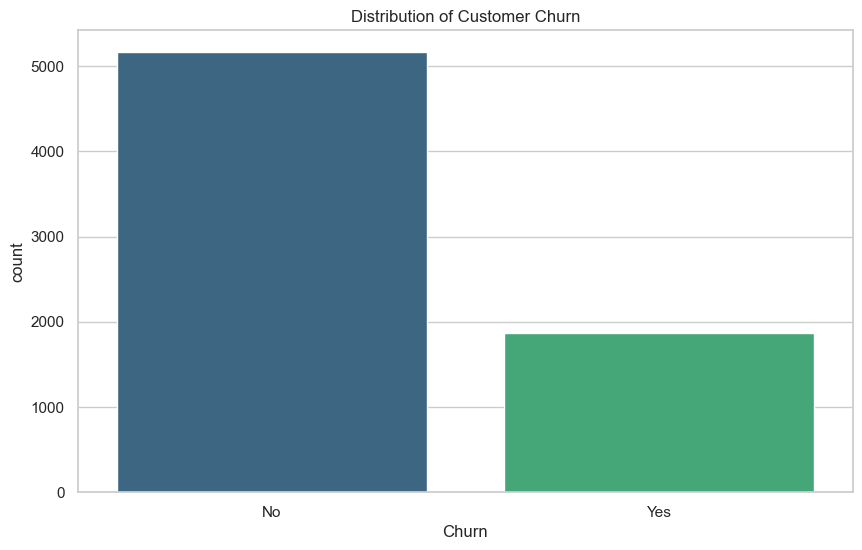

In [7]:
# Churn distribution to check for class imbalance
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Churn',hue='Churn',palette='viridis')
plt.title('Distribution of Customer Churn')
plt.show()

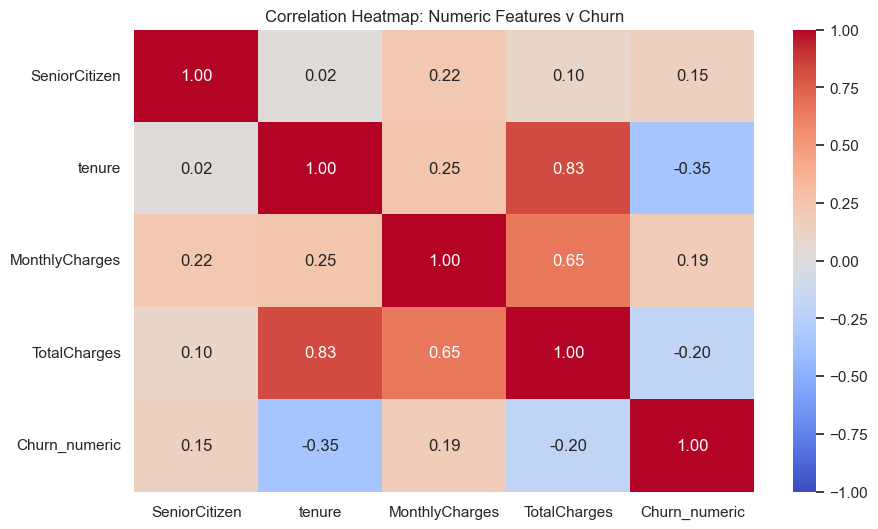

In [8]:
# Correlation heatmap
corr_matrix=df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm', fmt='.2f',vmin=-1,vmax=1)
plt.title('Correlation Heatmap: Numeric Features v Churn')
plt.show()

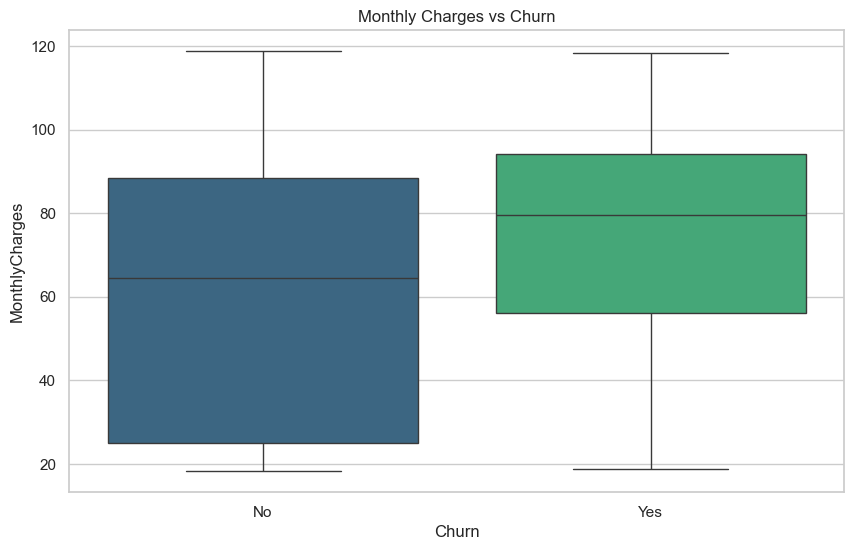

In [9]:
# Monthly charges impact
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Churn',hue='Churn', y='MonthlyCharges',palette='viridis')
plt.title('Monthly Charges vs Churn')
plt.show()

In [10]:
# validation for difference in monthly charges
churned_charges = df[df['Churn'] == 'Yes']['MonthlyCharges']
retained_charges = df[df['Churn'] == 'No']['MonthlyCharges']

t_stat, p_val = stats.ttest_ind(churned_charges,retained_charges)
print(f'T-statistic: {t_stat:.2f}')
print(f'P-Value: {p_val:.4e}')

T-statistic: 16.48
P-Value: 6.7608e-60


In [11]:
# Metric breakdown

# T-statistic: 16.48 indicates measurable gap between two groups
# P-Value: 6.7608e-60 is virtually zero, below standard threshold of 0.5 (reject null hypothesis) 

# Feature Engineering Pipeline

In [12]:
# Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [13]:
# feature selection
X = df.drop(columns=['Churn','TotalCharges']) # drop total charges as it is simply tenure * monthlycharges (multicollinearity)
y = df['Churn'].map({'Yes':1, 'No':0})

# numeric columns
numeric_features = ['tenure','SeniorCitizen','MonthlyCharges']

# collect text columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# preprocessing stpes / transformers

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', # prevent crash if new category
                             drop='first', # drops 1 encode column for collinear features
                             sparse_output=False)) # store output in memory
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Number rows & columns before pipeline: {X_train.shape}') 

Number rows & columns before pipeline: (5625, 19)


# Models & MLflow Tracking

In [14]:
# libraries
import mlflow
import mlflow.sklearn
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,confusion_matrix,RocCurveDisplay

In [21]:
# define models for experimenting
models = {
    'Logistic Regression': LogisticRegression(max_iter=100,random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100,random_state=42)
}

# initialize MLflow
mlflow.set_tracking_uri('http://localhost:5000')
experiment_name= 'Telco_Customer_Churn_Prediction'
mlflow.set_experiment(experiment_name)

# loop through models, train, evaluate, and log
for model_name, model in models.items():
    
    with mlflow.start_run(run_name=model_name): # start MLflow for each model

        # connect preprocessor to classifier
        clf_pipeline = Pipeline(steps=[
          ('preprocessor',preprocessor),
          ('classifier', model)
        ])

        # model train
        clf_pipeline.fit(X_train,y_train)

        # predict
        y_pred = clf_pipeline.predict(X_test)
        y_pred_proba = clf_pipeline.predict_proba(X_test)[:,1]

        # evaluate / metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test,y_pred)
        recall = recall_score(y_test,y_pred)
        f1= f1_score(y_test,y_pred)
        roc_auc =roc_auc_score(y_test,y_pred_proba)

        # results
        print(f' {model_name} ')
        print(f'Accuracy: {accuracy:.4f}')
        print(f'F1-Score: {f1:.4f}')
        print(f'ROC-AUC: {roc_auc:.4f}\n')

        # log metrics to MLflow
        mlflow.log_metric('accuracy',accuracy)
        mlflow.log_metric('precision',precision)
        mlflow.log_metric('recall',recall)
        mlflow.log_metric('f1_score',f1)
        mlflow.log_metric('roc_auc',roc_auc)

        # log sci-kit pipeline as artifacts
        mlflow.sklearn.log_model(clf_pipeline, 'model_pipeline')

print('Experiments complete')

 Logistic Regression 
Accuracy: 0.8031
F1-Score: 0.6082
ROC-AUC: 0.8336



2026/04/06 21:17:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 21:17:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Logistic Regression at: http://localhost:5000/#/experiments/1/runs/549e71bc46304416a4fbc35450bb4309
🧪 View experiment at: http://localhost:5000/#/experiments/1
 Random Forest 
Accuracy: 0.7804
F1-Score: 0.5436
ROC-AUC: 0.8133



2026/04/06 21:17:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 21:17:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Random Forest at: http://localhost:5000/#/experiments/1/runs/b32970db995e4305bac2964bced86ba6
🧪 View experiment at: http://localhost:5000/#/experiments/1
Experiments complete
